# Baseline models: XGB and local-trend-predictor

I've mainly been working on Influenza, though norovirus is supposed to also be an interesting one for this task.

In [1]:
!hpc-ticket
!hpc-mount wissdaten

In [2]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

In [3]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(1,8))

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


<EpiDataLoader(disease=influenza, aggr_level=03, date_range=(2012-06-01 - 2020-06-01), regions=411, data_rows=171387, normalized=Yes)>

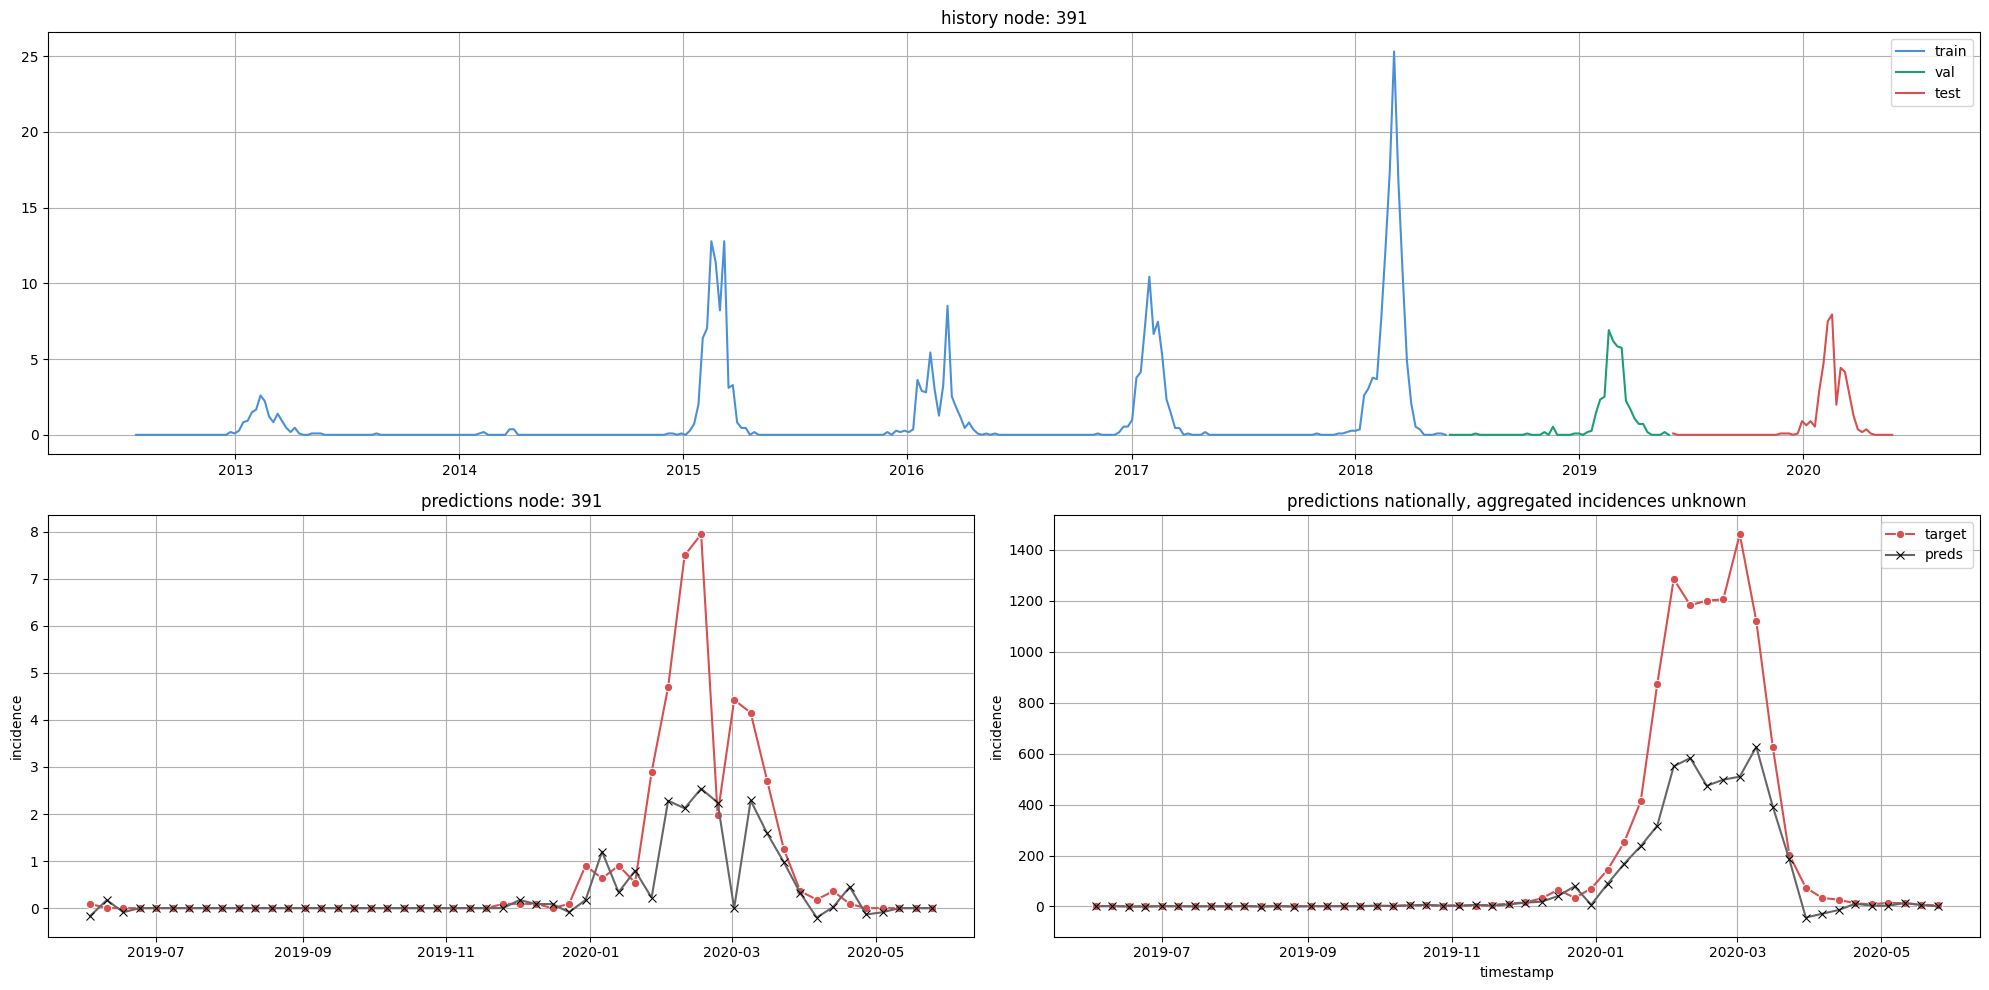

In [5]:
from src.models.localtrendpredictor import LocalTrendPredictor

dataloader_copy = epidata

ltp = LocalTrendPredictor(dataloader_copy)
ltp.forecast()
ltp.show_forecasts(391, norm=False)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[0]	train-rmse:0.96686	val-rmse:1.31464
[20]	train-rmse:0.48839	val-rmse:0.64549
[40]	train-rmse:0.37284	val-rmse:0.47198
[60]	train-rmse:0.34821	val-rmse:0.43456
[80]	train-rmse:0.33963	val-rmse:0.42661
[100]	train-rmse:0.33444	val-rmse:0.42524
[120]	train-rmse:0.33059	val-rmse:0.42470
[137]	train-rmse:0.32784	val-rmse:0.42533


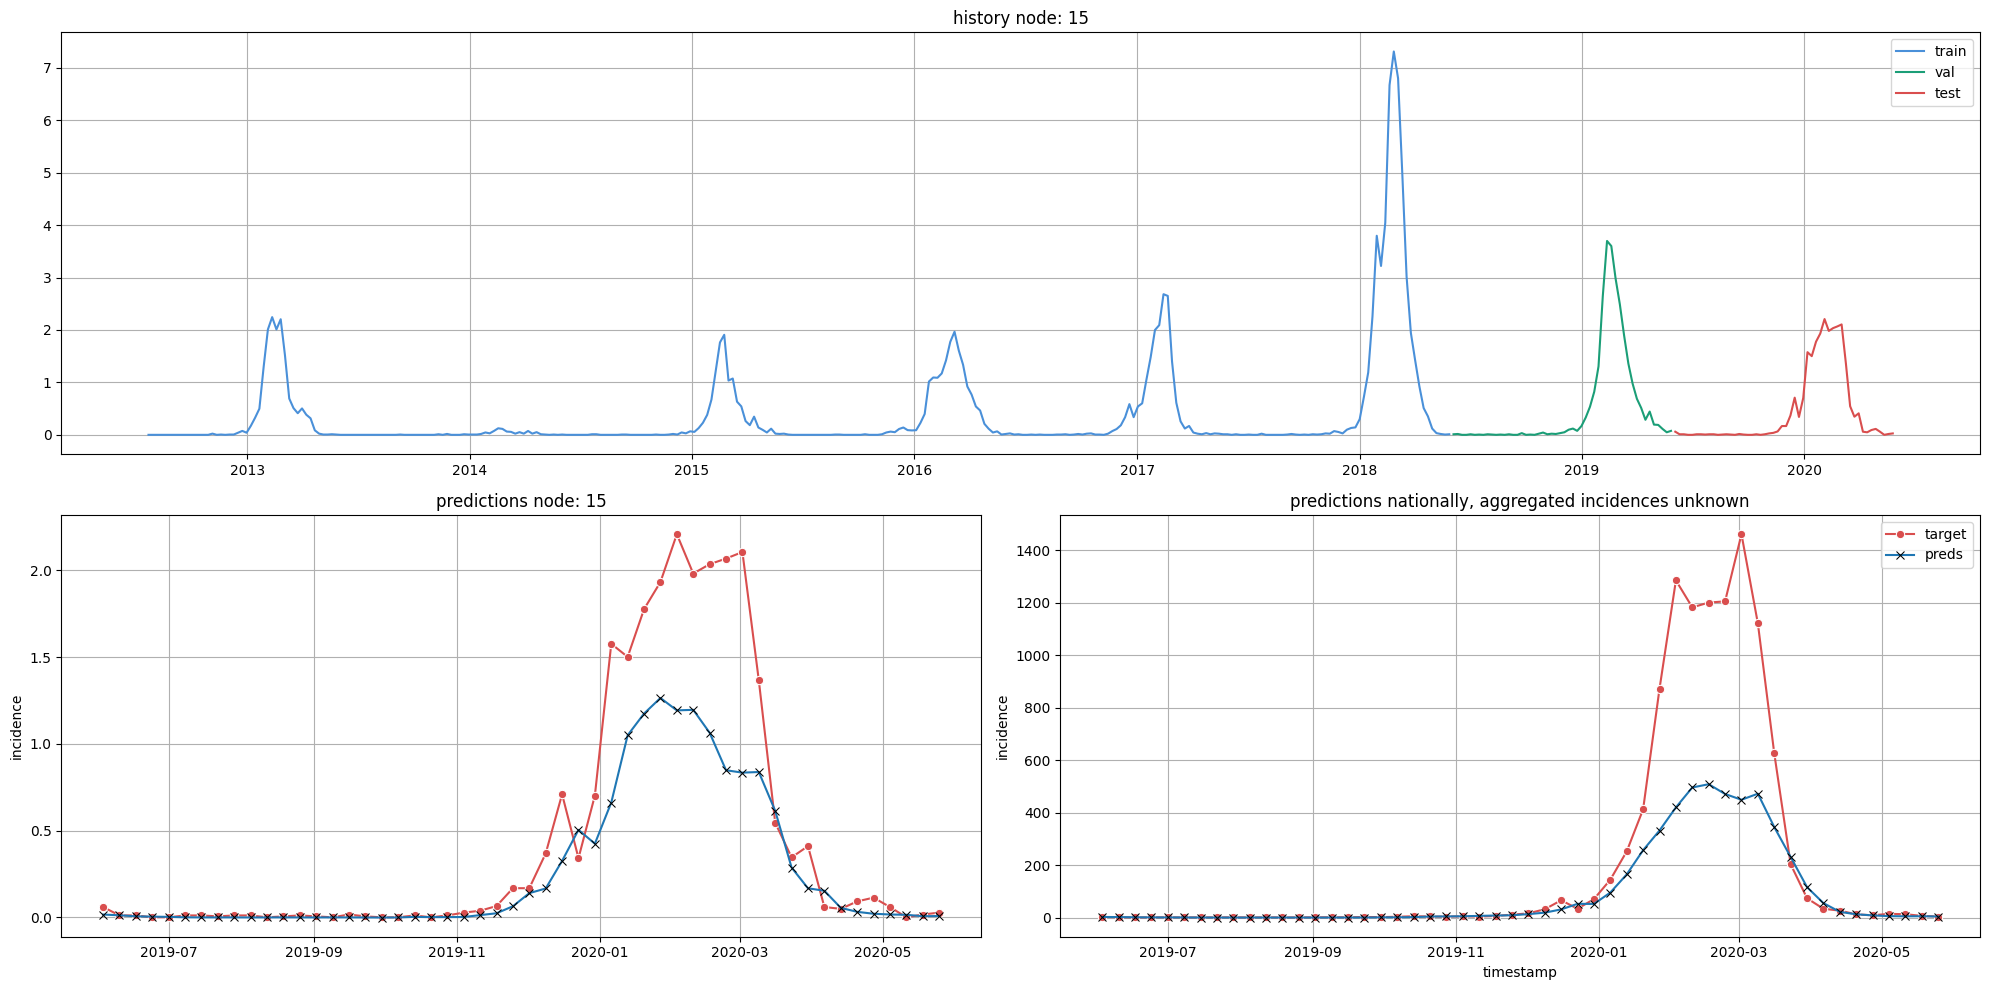

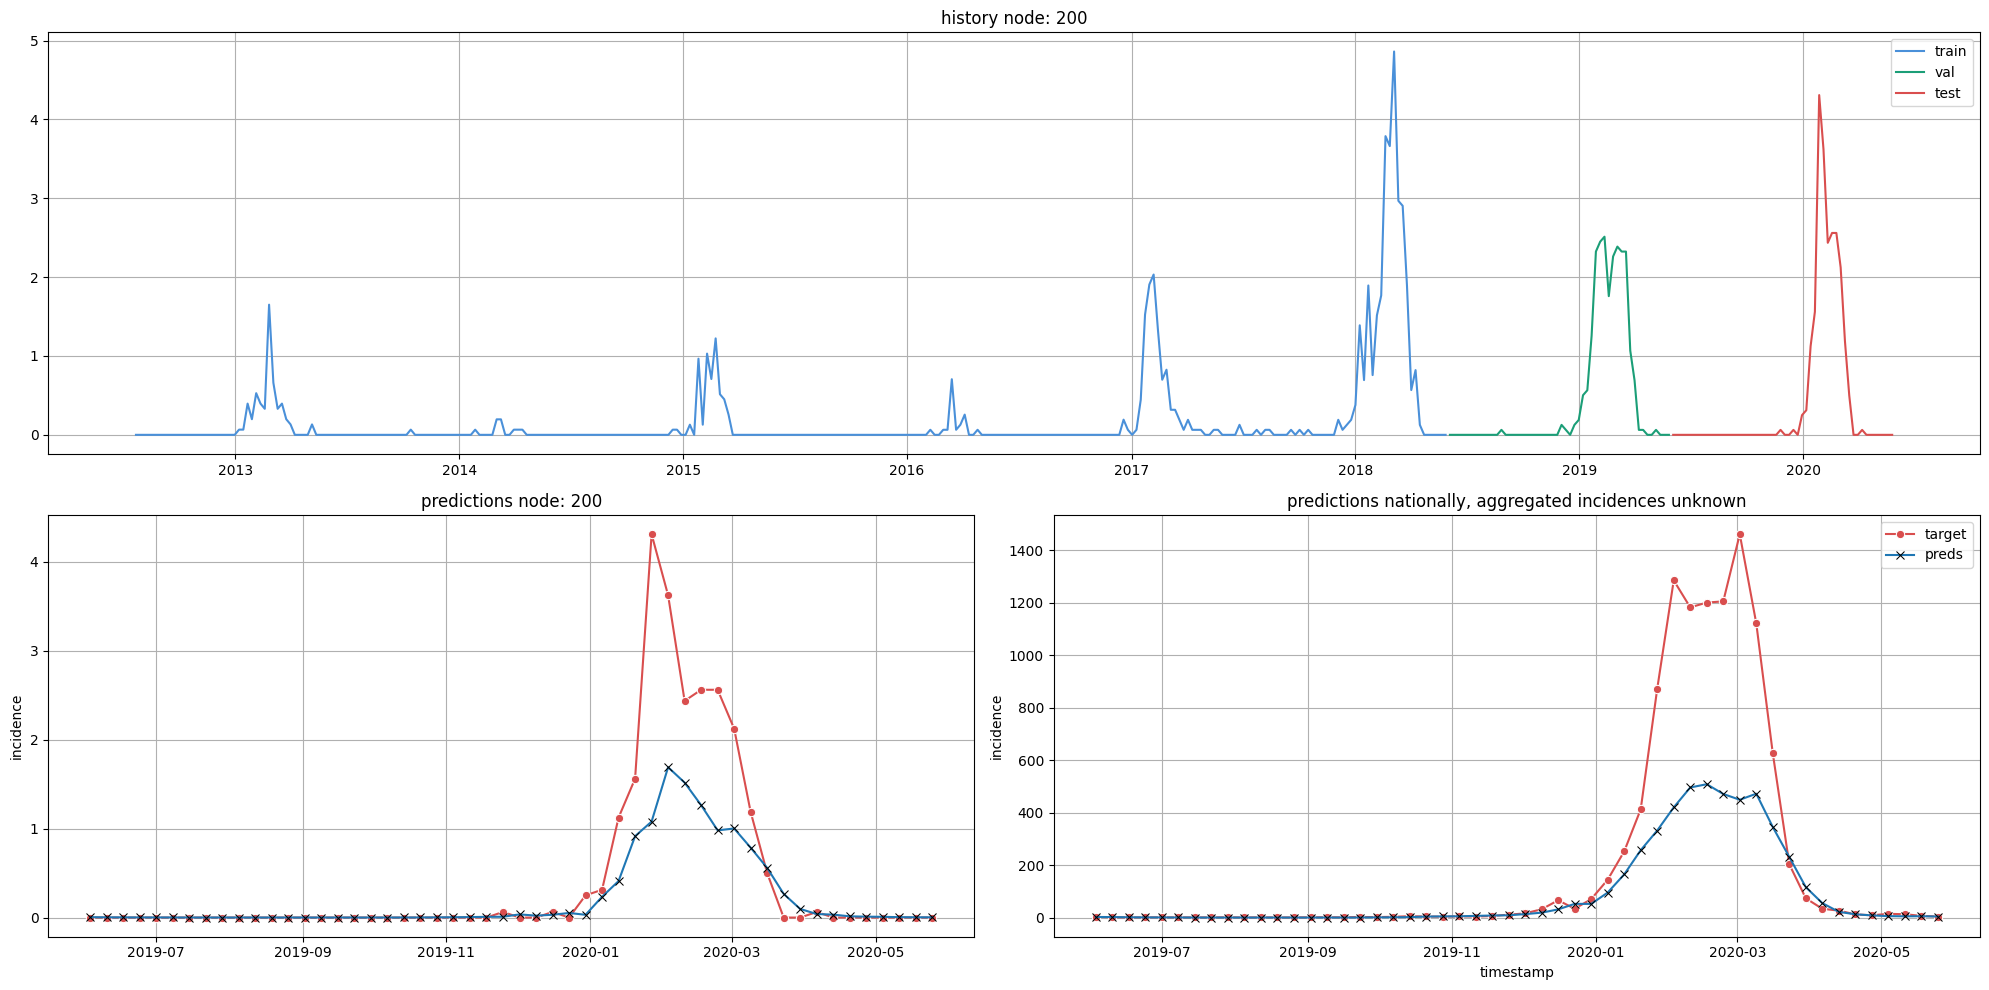

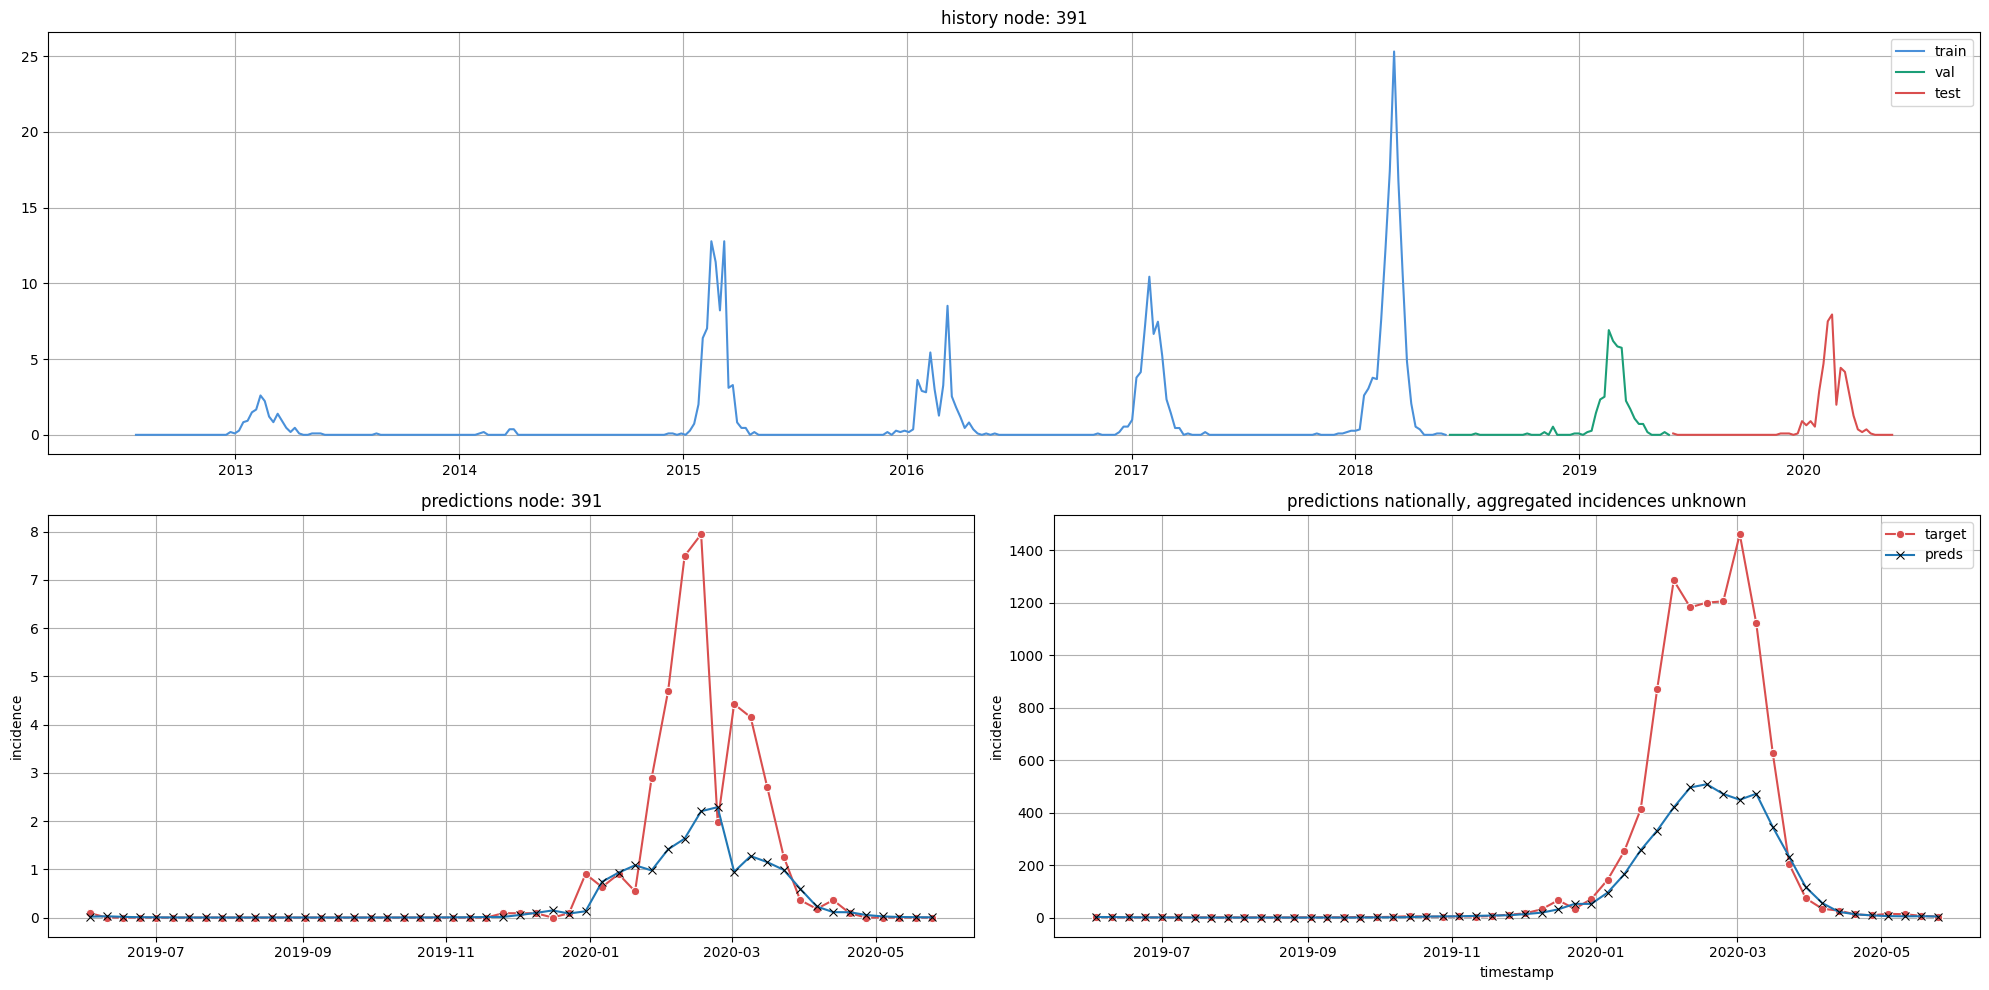

In [6]:
from src.models import XGBoostAutoRegressor
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

xgb_model = XGBoostAutoRegressor(epidata)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)

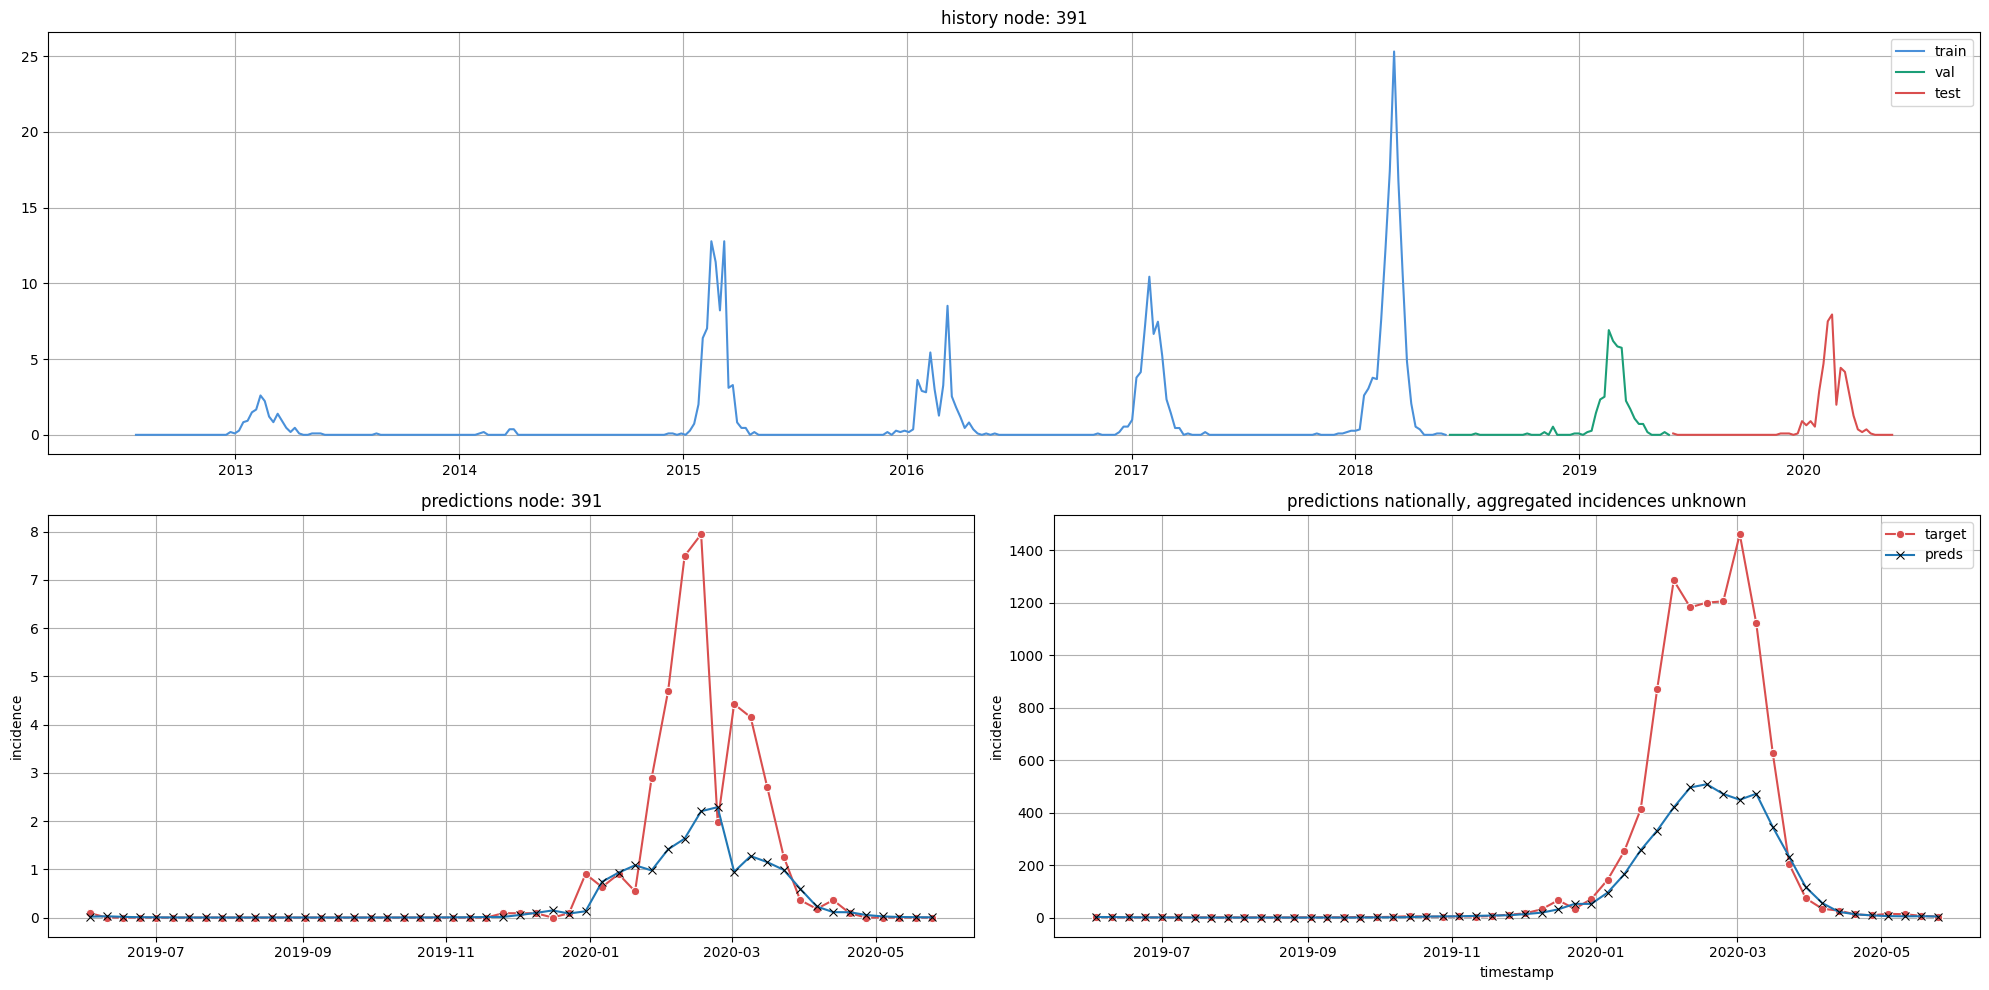

In [7]:
xgb_model.show_forecasts(391, norm=False)

[0]	train-rmse:0.97770	val-rmse:1.33049


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


[20]	train-rmse:0.66527	val-rmse:0.87362
[40]	train-rmse:0.58343	val-rmse:0.71898
[60]	train-rmse:0.55792	val-rmse:0.66316
[80]	train-rmse:0.54635	val-rmse:0.64748
[100]	train-rmse:0.53940	val-rmse:0.64071
[120]	train-rmse:0.53314	val-rmse:0.63939
[140]	train-rmse:0.52828	val-rmse:0.63889
[159]	train-rmse:0.52389	val-rmse:0.63971


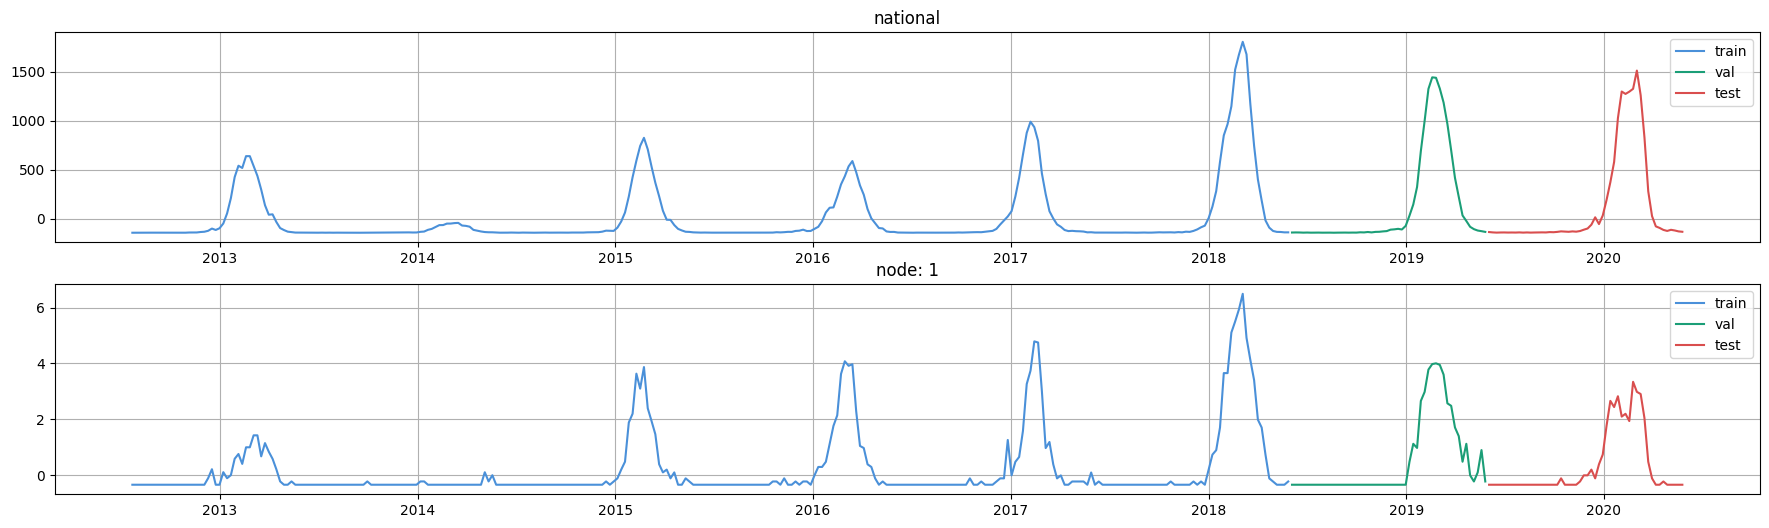

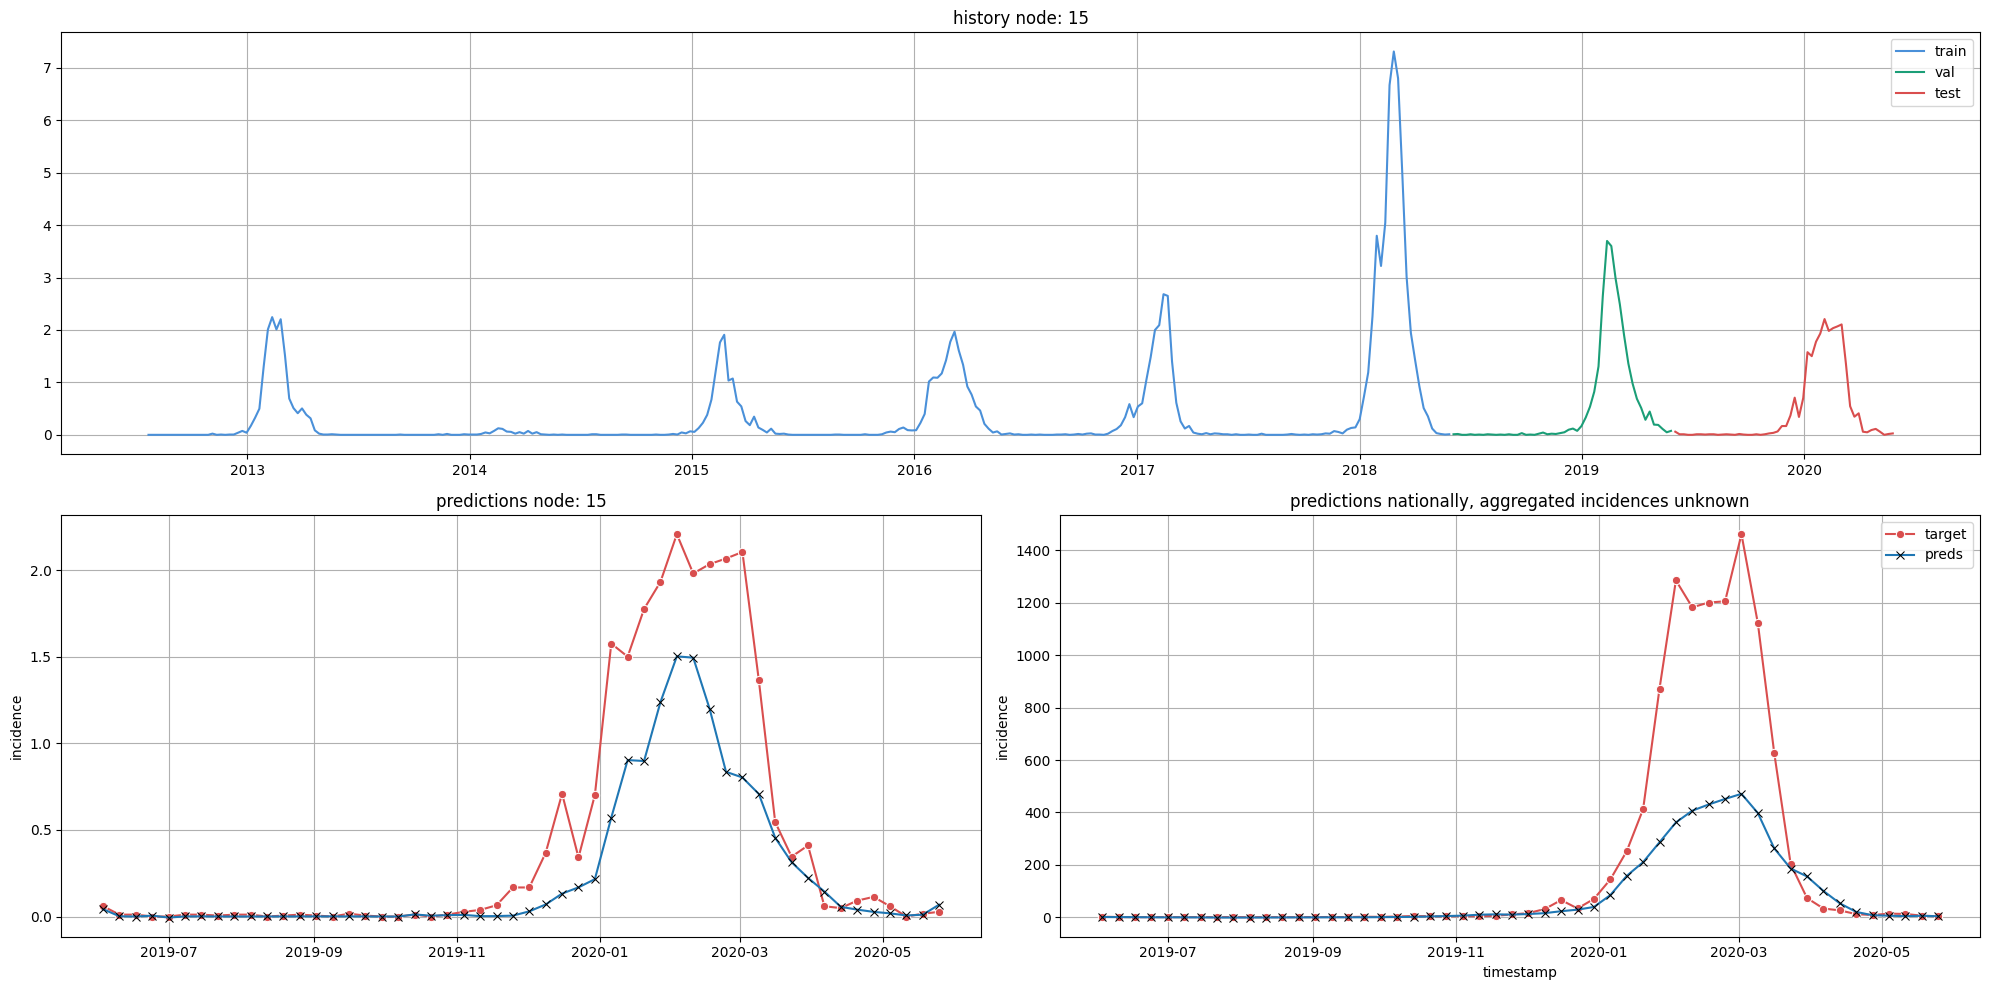

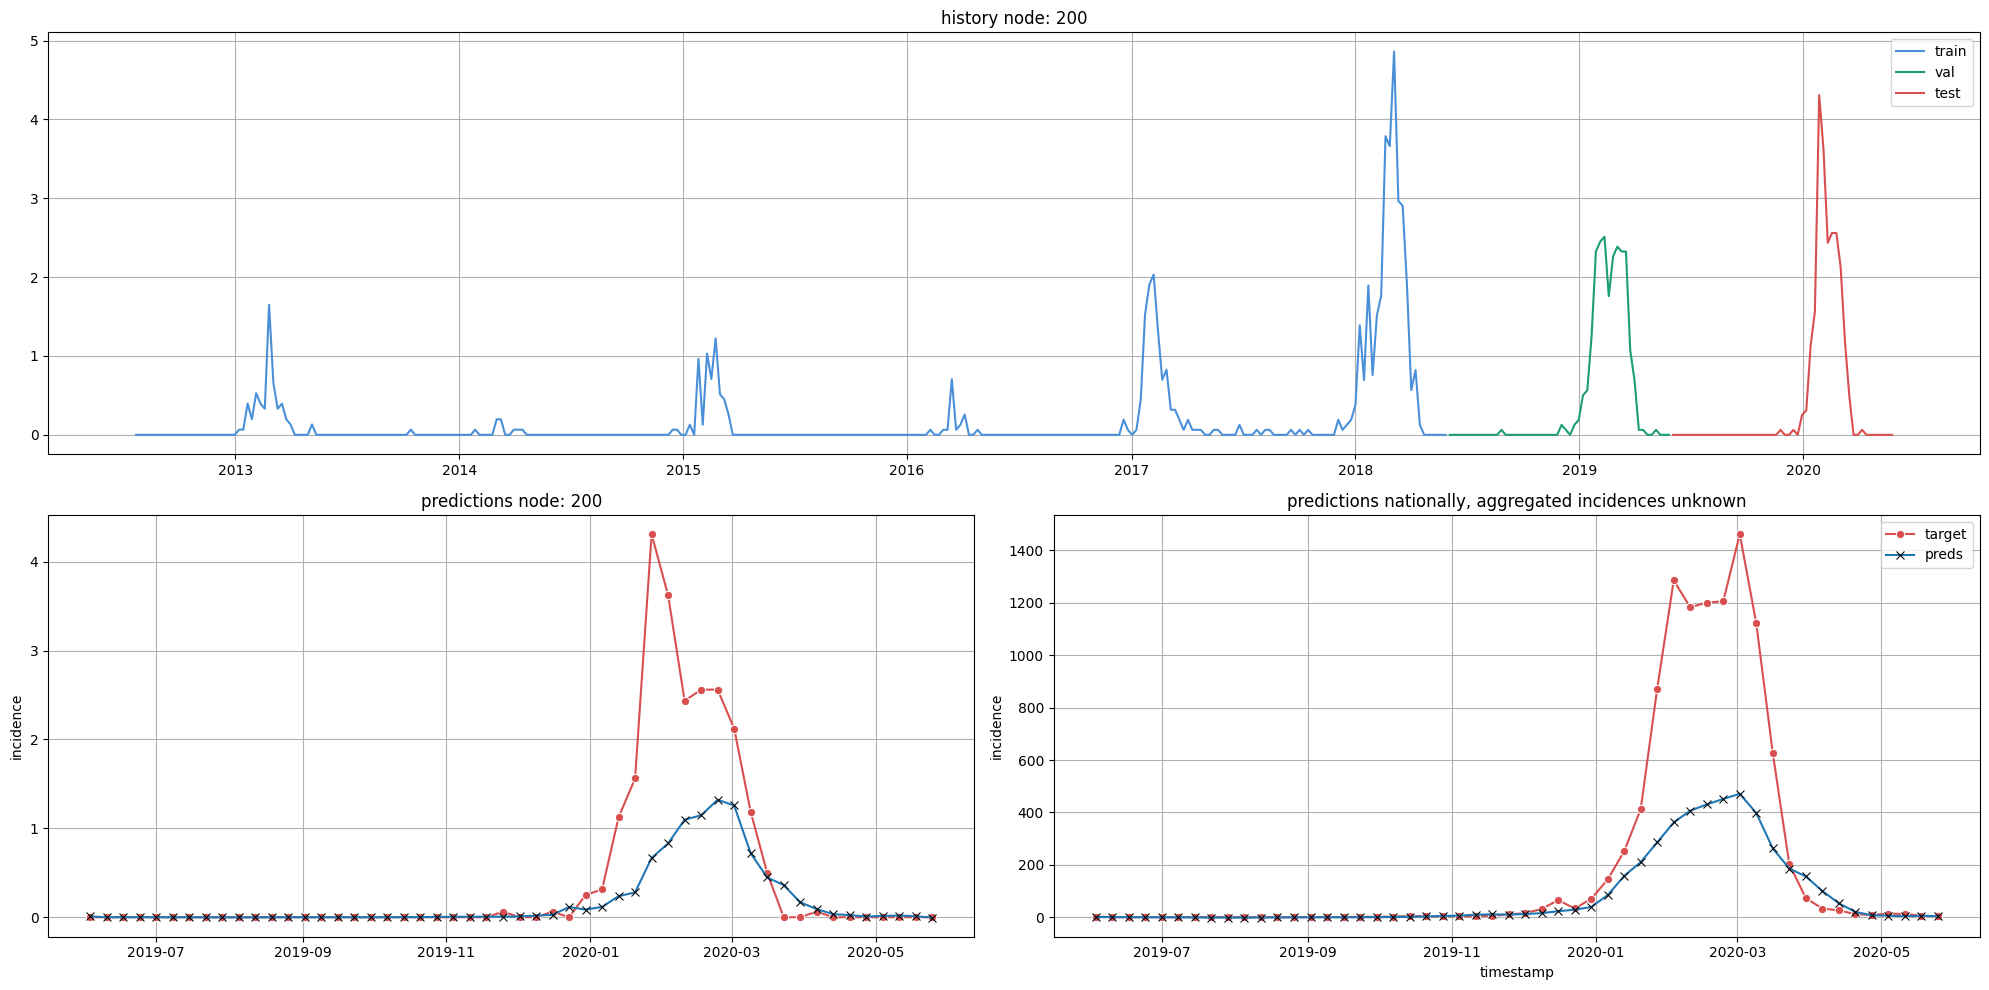

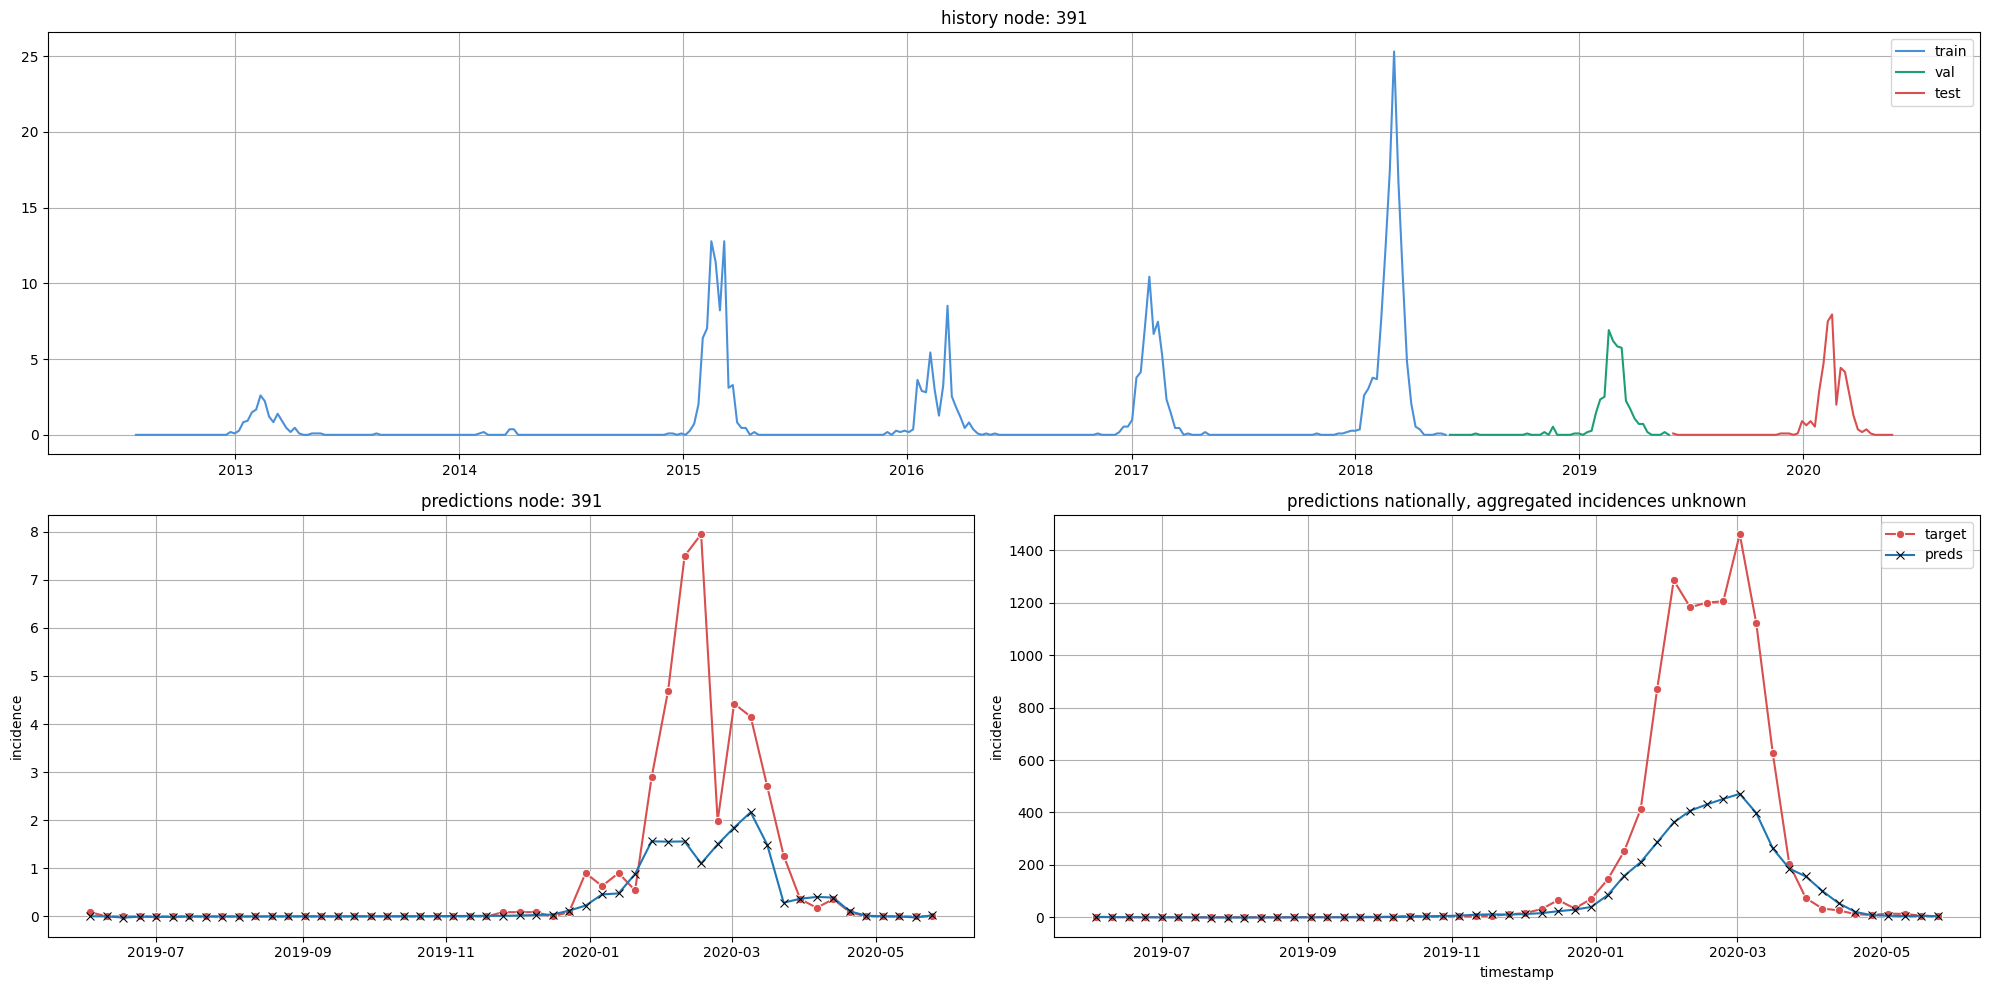

In [8]:
epidata = EpiDataLoader('influenza', data_env, aggr_level= '03', min_date='2012-06-01',max_date='2020-06-01')
epidata.add_time_features()
epidata.log_transform_target()
epidata.normalize('2018-06-01','2019-06-01','zscore')
epidata.add_lagged_features(range(4,8))
epidata.preview()

xgb_model = XGBoostAutoRegressor(epidata)
xgb_model.forecast()
xgb_model.show_forecasts(15)
xgb_model.show_forecasts(200)
xgb_model.show_forecasts(391)